In [71]:
%pip install numpy pandas matplotlib seaborn scikit-learn scikit-fuzzy datasets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Fuzzy C-Means implementation
import skfuzzy as fuzz

### Loading Dataset

In [73]:
from datasets import load_dataset

# Load the dataset directly from Hugging Face
print("Loading dataset...")
ds = load_dataset("millat/e-commerce-orders")
df = pd.DataFrame(ds['train'])

print(f"\nDataset Shape: {df.shape}")
print(f"Number of Orders: {len(df)}")
print(f"Number of Features: {len(df.columns)}")

Loading dataset...

Dataset Shape: (10000, 15)
Number of Orders: 10000
Number of Features: 15


In [74]:
df.head()

,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
0,b8ec9f86-5919-4b71-a5f7-945e7c0a3db0,2031,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP
1,5ea92c47-c5b2-4bdd-8a50-d77efd77ec89,2350,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning
2,5cc48ce0-2c6d-4448-af3f-96f8a910d45b,1818,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning
3,74d5c0f4-53f0-4367-a5c5-baaa114c2d9f,472,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP
4,7a630323-8ac8-406e-875a-4bcdead440ab,1075,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP


In [75]:
print("\nNumerical Features Summary:")
print(df[['price', 'quantity']].describe())

print("\nCategorical Features:")
for col in ['category', 'delivery_status', 'payment_method', 'device_type', 'channel', 'customer_segment']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Numerical Features Summary:
              price      quantity
count  10000.000000  10000.000000
mean     252.550681      2.124700
std      141.394146      1.254315
min        5.060000      1.000000
25%      130.607500      1.000000
50%      252.910000      2.000000
75%      374.917500      3.000000
max      499.930000      9.000000

Categorical Features:

category:
category
Home           1713
Electronics    1694
Beauty         1682
Toys           1666
Books          1625
Clothing       1620
Name: count, dtype: int64

delivery_status:
delivery_status
Delivered    7047
Shipped      1938
Pending       513
Returned      502
Name: count, dtype: int64

payment_method:
payment_method
Apple Pay      2068
Debit Card     2002
Google Pay     1986
PayPal         1977
Credit Card    1967
Name: count, dtype: int64

device_type:
device_type
Desktop    3383
Tablet     3339
Mobile     3278
Name: count, dtype: int64

channel:
channel
Social         2566
Paid Search    2525
Email          2474
Organic 

### Feature Engineering

In [76]:
# Calculate total order value
df['total_value'] = df['price'] * df['quantity']

customer_features = df.groupby('customer_id').agg({
    'order_id': 'count',  # Number of orders
    'total_value': ['sum','mean'],  # Spending patterns
    'quantity': ['mean'],  # Purchase volume
    'price': ['mean']  # Price preferences
}).reset_index()

In [77]:
# Flatten column names
customer_features.columns = ['customer_id', 'num_orders',  'total_spending',
                              'avg_order_value', 
                               'avg_quantity', 
                              'avg_price']

# Add categorical features using one-hot encoding
category_freq = df.groupby(['customer_id', 'category']).size().unstack(fill_value=0)
device_freq = df.groupby(['customer_id', 'device_type']).size().unstack(fill_value=0)
channel_freq = df.groupby(['customer_id', 'channel']).size().unstack(fill_value=0)

# Merge all features
customer_features = customer_features.merge(category_freq, on='customer_id', how='left')
customer_features = customer_features.merge(device_freq, on='customer_id', how='left')
customer_features = customer_features.merge(channel_freq, on='customer_id', how='left')

# Turn them into percentage features
for col in category_freq.columns:
    customer_features[col] = customer_features[col] / customer_features['num_orders']

for col in device_freq.columns:
    customer_features[col] = customer_features[col] / customer_features['num_orders']

for col in channel_freq.columns:
    customer_features[col] = customer_features[col] / customer_features['num_orders']
    
# Fill any remaining NaN
customer_features.fillna(0, inplace=True)

print(f"\nCustomer-level features shape: {customer_features.shape}")
print(f"Number of customers: {len(customer_features)}")
print("\nFeature columns:")
print(customer_features.columns.tolist())


Customer-level features shape: (2713, 19)
Number of customers: 2713

Feature columns:
['customer_id', 'num_orders', 'total_spending', 'avg_order_value', 'avg_quantity', 'avg_price', 'Beauty', 'Books', 'Clothing', 'Electronics', 'Home', 'Toys', 'Desktop', 'Mobile', 'Tablet', 'Email', 'Organic', 'Paid Search', 'Social']


In [78]:
customer_features

,customer_id,num_orders,total_spending,avg_order_value,avg_quantity,avg_price,Beauty,Books,Clothing,Electronics,Home,Toys,Desktop,Mobile,Tablet,Email,Organic,Paid Search,Social
0,1,274,142600.00,520.437956,2.109489,242.296971,0.138686,0.160584,0.178832,0.186131,0.182482,0.153285,0.317518,0.375912,0.306569,0.251825,0.229927,0.259124,0.259124
1,2,49,25766.89,525.854898,2.163265,234.441224,0.122449,0.142857,0.204082,0.142857,0.163265,0.224490,0.224490,0.306122,0.469388,0.367347,0.183673,0.285714,0.163265
2,3,71,36709.49,517.035070,2.422535,210.747606,0.225352,0.197183,0.126761,0.169014,0.154930,0.126761,0.295775,0.380282,0.323944,0.281690,0.183099,0.197183,0.338028
3,4,31,19690.36,635.172903,2.096774,296.322903,0.193548,0.064516,0.096774,0.354839,0.096774,0.193548,0.258065,0.451613,0.290323,0.258065,0.387097,0.161290,0.193548
4,5,39,19710.87,505.406923,2.025641,246.239231,0.102564,0.179487,0.205128,0.153846,0.256410,0.102564,0.333333,0.410256,0.256410,0.333333,0.128205,0.256410,0.282051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2708,2995,3,1751.77,583.923333,2.000000,261.946667,0.333333,0.000000,0.000000,0.333333,0.333333,0.000000,0.333333,0.333333,0.333333,0.000000,0.000000,0.333333,0.666667
2709,2996,2,861.54,430.770000,2.500000,208.140000,0.000000,0.500000,0.000000,0.000000,0.000000,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,1.000000
2710,2997,2,506.79,253.395000,1.000000,253.395000,0.000000,0.500000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
2711,2998,1,123.94,123.940000,1.000000,123.940000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000


### Data Preparation

In [79]:
# Select features for clustering (exclude customer_id)
feature_cols = [col for col in customer_features.columns if col != 'customer_id']
X = customer_features[feature_cols].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Number of features used: {len(feature_cols)}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Feature matrix shape: (2713, 18)
Number of features used: 18


### DETERMINE OPTIMAL NUMBER OF CLUSTERS


Testing cluster numbers from 2 to 7...
k=2: Intertia=45603.701 Silhouette=0.074, DB=3.310, CH=192.0
k=3: Intertia=43337.188 Silhouette=0.064, DB=3.096, CH=171.9
k=4: Intertia=40051.005 Silhouette=0.062, DB=2.368, CH=198.0
k=5: Intertia=37963.365 Silhouette=0.067, DB=2.189, CH=193.9
k=6: Intertia=37014.545 Silhouette=0.068, DB=2.282, CH=172.9
k=7: Intertia=35487.957 Silhouette=0.076, DB=2.161, CH=169.6


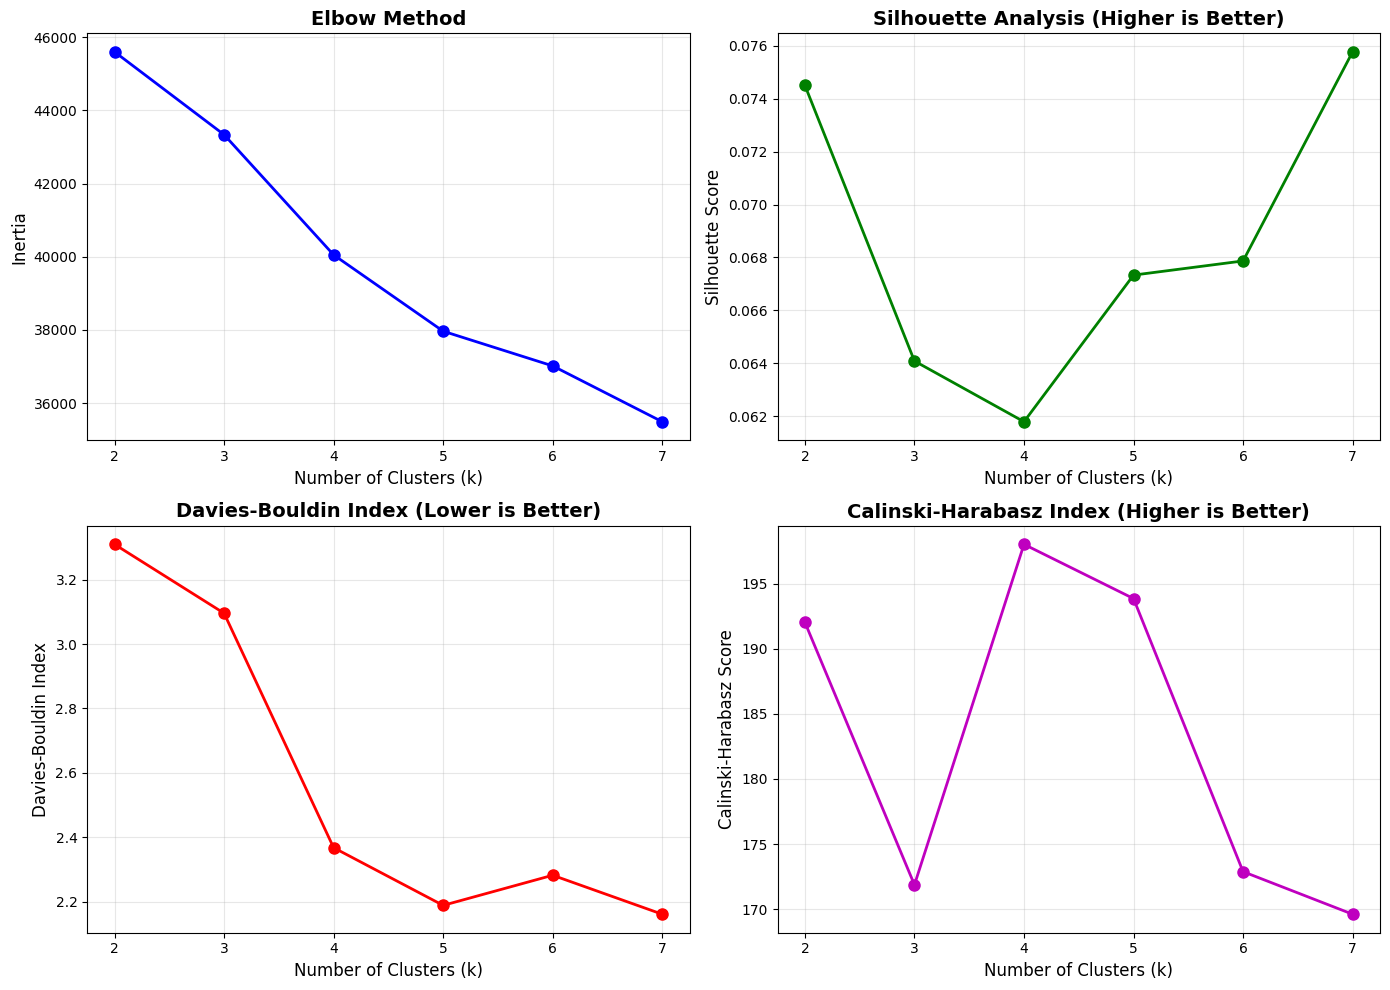

In [97]:
# Test different numbers of clusters
k_range = range(2, 8)
inertias = []
silhouette_scores = []
db_scores = []
ch_scores = []

print("\nTesting cluster numbers from 2 to 7...")

for k in k_range:
    # Fit KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    
    print(f"k={k}: Intertia={inertias[-1]:.3f} Silhouette={silhouette_scores[-1]:.3f}, "
          f"DB={db_scores[-1]:.3f}, CH={ch_scores[-1]:.1f}")

# Plot elbow curve and metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia', fontsize=12)
axes[0, 0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Analysis (Higher is Better)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(k_range, db_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 0].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(k_range, ch_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1, 1].set_title('Calinski-Harabasz Index (Higher is Better)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('charts/cluster_evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [81]:
# Select optimal k
optimal_k = 5  # Based on evaluation metrics
print(f"\n✓ Selected optimal number of clusters: {optimal_k}")


✓ Selected optimal number of clusters: 5


### HARD C-MEANS CLUSTERING (K-MEANS)

In [82]:
# Apply K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
hard_labels = kmeans.fit_predict(X_scaled)

# Evaluation metrics
hard_silhouette = silhouette_score(X_scaled, hard_labels)
hard_db = davies_bouldin_score(X_scaled, hard_labels)
hard_ch = calinski_harabasz_score(X_scaled, hard_labels)

print(f"\nHard C-Means Results:")
print(f"  Silhouette Score: {hard_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {hard_db:.4f}")
print(f"  Calinski-Harabasz Score: {hard_ch:.2f}")

print("\nCluster Distribution:")
unique, counts = np.unique(hard_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} customers ({count/len(hard_labels)*100:.1f}%)")



Hard C-Means Results:
  Silhouette Score: 0.0673
  Davies-Bouldin Index: 2.1886
  Calinski-Harabasz Score: 193.86

Cluster Distribution:
  Cluster 0: 650 customers (24.0%)
  Cluster 1: 665 customers (24.5%)
  Cluster 2: 608 customers (22.4%)
  Cluster 3: 789 customers (29.1%)
  Cluster 4: 1 customers (0.0%)


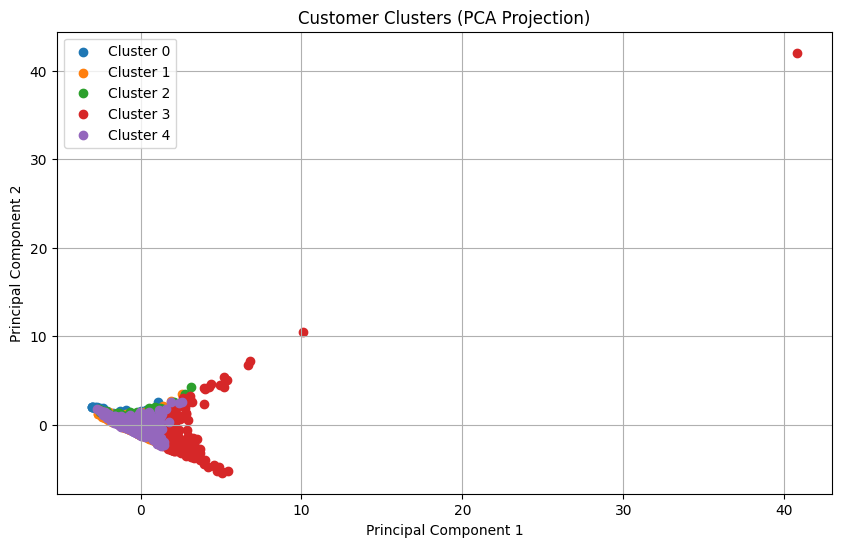

In [96]:
# Reduce Dimensions to 2D (to allow plotting)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# We plot the 2 PCA components, filtering by the cluster label
plt.figure(figsize=(10, 6))

for i in range(0,optimal_k):
    # Scatter plot for Cluster i
    plt.scatter(X_pca[hard_labels == i, 0], X_pca[hard_labels == i, 1], label=f'Cluster {i}')

plt.grid(True)
plt.title('Customer Clusters (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.savefig('charts/pca_customer_cluster_hard.png', dpi=300, bbox_inches='tight')
plt.show()

### FUZZY C-MEANS CLUSTERING


Testing cluster numbers from 2 to 7...
k=2: m=1.1 FPC=0.802
k=2: m=1.5 FPC=0.500
k=2: m=2.0 FPC=0.500
k=2: m=2.5 FPC=0.500
k=3: m=1.1 FPC=0.756
k=3: m=1.5 FPC=0.333
k=3: m=2.0 FPC=0.333
k=3: m=2.5 FPC=0.333
k=4: m=1.1 FPC=0.750
k=4: m=1.5 FPC=0.250
k=4: m=2.0 FPC=0.250
k=4: m=2.5 FPC=0.250
k=5: m=1.1 FPC=0.747
k=5: m=1.5 FPC=0.200
k=5: m=2.0 FPC=0.200
k=5: m=2.5 FPC=0.200
k=6: m=1.1 FPC=0.725
k=6: m=1.5 FPC=0.167
k=6: m=2.0 FPC=0.167
k=6: m=2.5 FPC=0.167
k=7: m=1.1 FPC=0.716
k=7: m=1.5 FPC=0.143
k=7: m=2.0 FPC=0.143
k=7: m=2.5 FPC=0.143


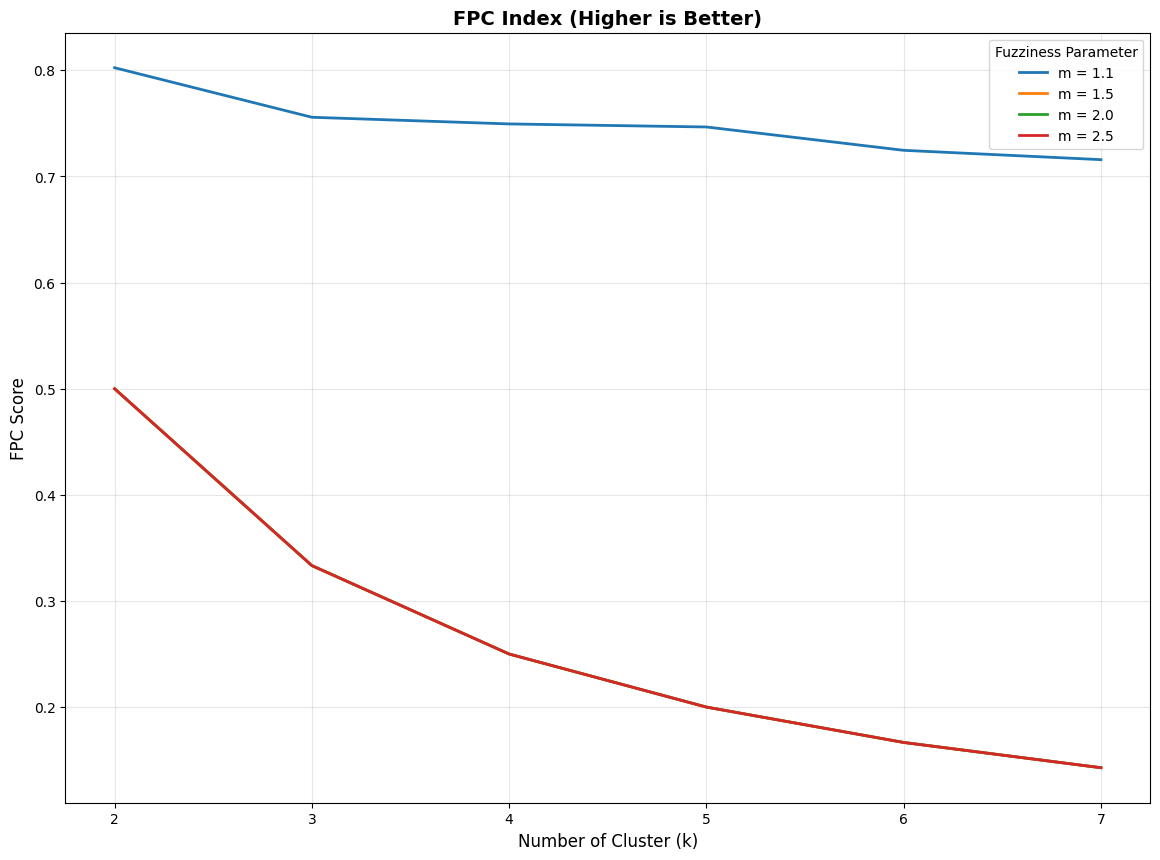

In [98]:
# Test different numbers of clusters
k_range = range(2, 8)
m_range = [1.1, 1.5, 2.0, 2.5]
inertias = []

fpc_score = {m: [] for m in m_range}
print("\nTesting cluster numbers from 2 to 7...")

for k in k_range:
    for j in m_range:
        # Fit KMeans
        cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
            X_scaled.T, 
            c=k, 
            m=j,  # Fuzziness parameter 
            error=0.005, 
            maxiter=1000, 
            init=None
        )
        fpc_score[j].append(fpc)       
        print(f"k={k}: m={j} FPC={fpc_score[j][-1]:.3f}")

# Plot elbow curve and metrics
fig, axes = plt.subplots(1, 1, figsize=(14, 10))

for i,m in enumerate(m_range):
    axes.plot(k_range, fpc_score[m], linewidth=2, markersize=8, label=f'm = {m}')
    
axes.set_xlabel('Number of Cluster (k)', fontsize=12)
axes.set_ylabel('FPC Score', fontsize=12)
axes.set_title('FPC Index (Higher is Better)', fontsize=14, fontweight='bold')
axes.legend(title="Fuzziness Parameter")
axes.grid(True, alpha=0.3)

plt.savefig('charts/fuzzy_cluster_evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [86]:
# Select optimal k
optimal_k = 5  # Based on evaluation metrics
optimal_m = 1.1  # Based on evaluation metrics
print(f"\n✓ Selected optimal number of clusters: {optimal_k}")


✓ Selected optimal number of clusters: 5


In [88]:
# Apply Fuzzy C-Means
# Note: scikit-fuzzy requires transposed data (features x samples)
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_scaled.T, 
    c=optimal_k, 
    m=optimal_m,  # Fuzziness parameter (typically between 1.5 and 2.5)
    error=0.005, 
    maxiter=1000, 
    init=None
)

# Get hard labels from fuzzy memberships (for comparison)
fuzzy_hard_labels = np.argmax(u, axis=0)

# Evaluation metrics using hard assignment
fuzzy_silhouette = silhouette_score(X_scaled, fuzzy_hard_labels)
fuzzy_db = davies_bouldin_score(X_scaled, fuzzy_hard_labels)
fuzzy_ch = calinski_harabasz_score(X_scaled, fuzzy_hard_labels)

print(f"\nFuzzy C-Means Results:")
print(f"  Silhouette Score: {fuzzy_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {fuzzy_db:.4f}")
print(f"  Calinski-Harabasz Score: {fuzzy_ch:.2f}")
print(f"  Fuzzy Partition Coefficient (FPC): {fpc:.4f}")
print(f"    (FPC closer to 1 indicates crisper clusters)")

print("\nCluster Distribution:")
unique, counts = np.unique(fuzzy_hard_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} customers ({count/len(fuzzy_hard_labels)*100:.1f}%)")




Fuzzy C-Means Results:
  Silhouette Score: 0.0614
  Davies-Bouldin Index: 2.5685
  Calinski-Harabasz Score: 145.59
  Fuzzy Partition Coefficient (FPC): 0.7354
    (FPC closer to 1 indicates crisper clusters)

Cluster Distribution:
  Cluster 0: 535 customers (19.7%)
  Cluster 1: 624 customers (23.0%)
  Cluster 2: 530 customers (19.5%)
  Cluster 3: 496 customers (18.3%)
  Cluster 4: 528 customers (19.5%)


### COMPARISON OF HARD vs FUZZY CLUSTERING

In [89]:
# Find customers with uncertain memberships
max_memberships = np.max(u, axis=0)
min_memberships = np.min(u, axis=0)
membership_uncertainty = 1 - (max_memberships - min_memberships)

# Categorize customers by certainty
high_certainty = np.sum(max_memberships > 0.8)
medium_certainty = np.sum((max_memberships > 0.5) & (max_memberships <= 0.8))
low_certainty = np.sum(max_memberships <= 0.5)

print(f"\nMembership Certainty Analysis:")
print(f"  High Certainty (>80%): {high_certainty} customers ({high_certainty/len(max_memberships)*100:.1f}%)")
print(f"  Medium Certainty (50-80%): {medium_certainty} customers ({medium_certainty/len(max_memberships)*100:.1f}%)")
print(f"  Low Certainty (<50%): {low_certainty} customers ({low_certainty/len(max_memberships)*100:.1f}%)")

print(f"\n✓ {low_certainty + medium_certainty} customers ({(low_certainty + medium_certainty)/len(max_memberships)*100:.1f}%) "
      f"exhibit overlapping behaviors!")
print("  This is WHY fuzzy clustering is superior for this dataset.")

# Show examples of fuzzy customers
print("\nExample: Customers with Overlapping Memberships")
print("-" * 60)
uncertain_indices = np.where(max_memberships < 0.7)[0][:3]
for idx in uncertain_indices:
    memberships = u[:, idx]
    print(f"\nCustomer {customer_features.iloc[idx]['customer_id']}:")
    for cluster_id in range(optimal_k):
        print(f"  Cluster {cluster_id}: {memberships[cluster_id]:.3f}")


Membership Certainty Analysis:
  High Certainty (>80%): 1707 customers (62.9%)
  Medium Certainty (50-80%): 810 customers (29.9%)
  Low Certainty (<50%): 196 customers (7.2%)

✓ 1006 customers (37.1%) exhibit overlapping behaviors!
  This is WHY fuzzy clustering is superior for this dataset.

Example: Customers with Overlapping Memberships
------------------------------------------------------------

Customer 1.0:
  Cluster 0: 0.190
  Cluster 1: 0.193
  Cluster 2: 0.195
  Cluster 3: 0.228
  Cluster 4: 0.193

Customer 2.0:
  Cluster 0: 0.160
  Cluster 1: 0.136
  Cluster 2: 0.158
  Cluster 3: 0.363
  Cluster 4: 0.183

Customer 3.0:
  Cluster 0: 0.159
  Cluster 1: 0.170
  Cluster 2: 0.179
  Cluster 3: 0.317
  Cluster 4: 0.175


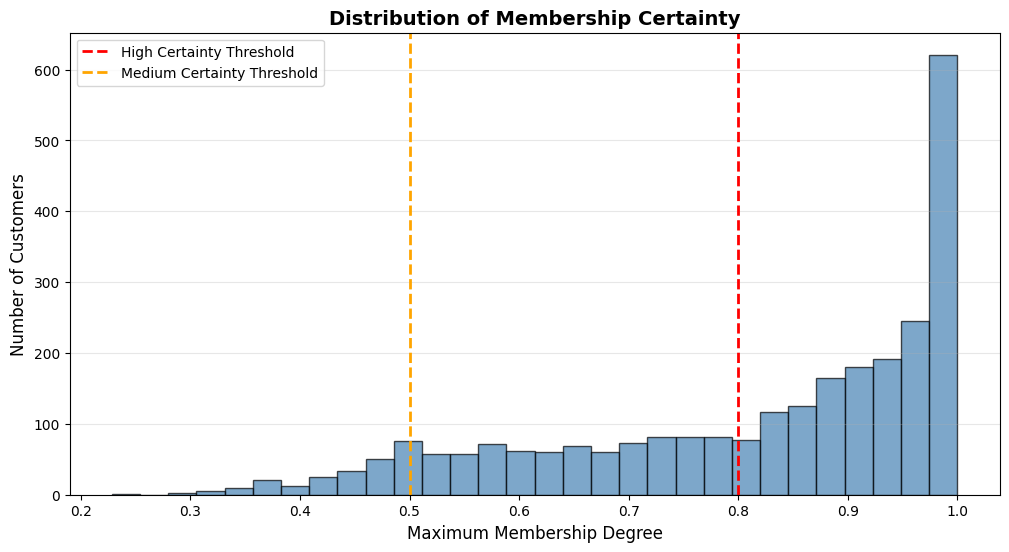

In [99]:
# 3. Membership uncertainty distribution
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(max_memberships, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(0.8, color='red', linestyle='--', linewidth=2, label='High Certainty Threshold')
ax.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Medium Certainty Threshold')
ax.set_xlabel('Maximum Membership Degree', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_title('Distribution of Membership Certainty', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.savefig('charts/distribution_membership.png', dpi=300, bbox_inches='tight')
plt.show()

### BUSINESS INSIGHTS FROM FUZZY CLUSTERING

In [91]:
# Add results to customer features
customer_features['hard_cluster'] = hard_labels
customer_features['fuzzy_cluster'] = fuzzy_hard_labels

# Add membership degrees
for c in range(optimal_k):
    customer_features[f'membership_cluster_{c}'] = u[c]

customer_features['max_membership'] = max_memberships
customer_features['membership_uncertainty'] = membership_uncertainty

# Characterize clusters using original features
print("\nCluster Characterization (using Fuzzy C-Means):")
print("=" * 60)

for cluster_id in range(optimal_k):
    print(f"\nCLUSTER {cluster_id}:")
    print("-" * 60)
    
    # Get customers with high membership to this cluster
    cluster_mask = u[cluster_id] > 0.5
    cluster_data = customer_features[cluster_mask]
    
    print(f"Size: {len(cluster_data)} customers")
    print(f"\nKey Characteristics:")
    print(f"  Avg. Number of Orders: {cluster_data['num_orders'].mean():.2f}")
    print(f"  Avg. Total Spending: ${cluster_data['total_spending'].mean():.2f}")
    print(f"  Avg. Price Spending: ${cluster_data['avg_price'].mean():.2f}")
    print(f"  Avg. Order Value: ${cluster_data['avg_order_value'].mean():.2f}")
    print(f"  Avg. Quantity per Order: {cluster_data['avg_quantity'].mean():.2f}")
    
    # Most common categories
    category_cols = [col for col in cluster_data.columns if col in df['category'].unique()]
    if category_cols:
        top_category = cluster_data[category_cols].sum().idxmax()
        print(f"  Preferred Category: {top_category}")


Cluster Characterization (using Fuzzy C-Means):

CLUSTER 0:
------------------------------------------------------------
Size: 510 customers

Key Characteristics:
  Avg. Number of Orders: 3.08
  Avg. Total Spending: $1305.19
  Avg. Price Spending: $221.70
  Avg. Order Value: $397.57
  Avg. Quantity per Order: 1.91
  Preferred Category: Electronics

CLUSTER 1:
------------------------------------------------------------
Size: 590 customers

Key Characteristics:
  Avg. Number of Orders: 3.38
  Avg. Total Spending: $1479.32
  Avg. Price Spending: $234.28
  Avg. Order Value: $423.70
  Avg. Quantity per Order: 1.88
  Preferred Category: Electronics

CLUSTER 2:
------------------------------------------------------------
Size: 480 customers

Key Characteristics:
  Avg. Number of Orders: 3.36
  Avg. Total Spending: $1508.00
  Avg. Price Spending: $238.27
  Avg. Order Value: $430.97
  Avg. Quantity per Order: 1.89
  Preferred Category: Clothing

CLUSTER 3:
------------------------------------

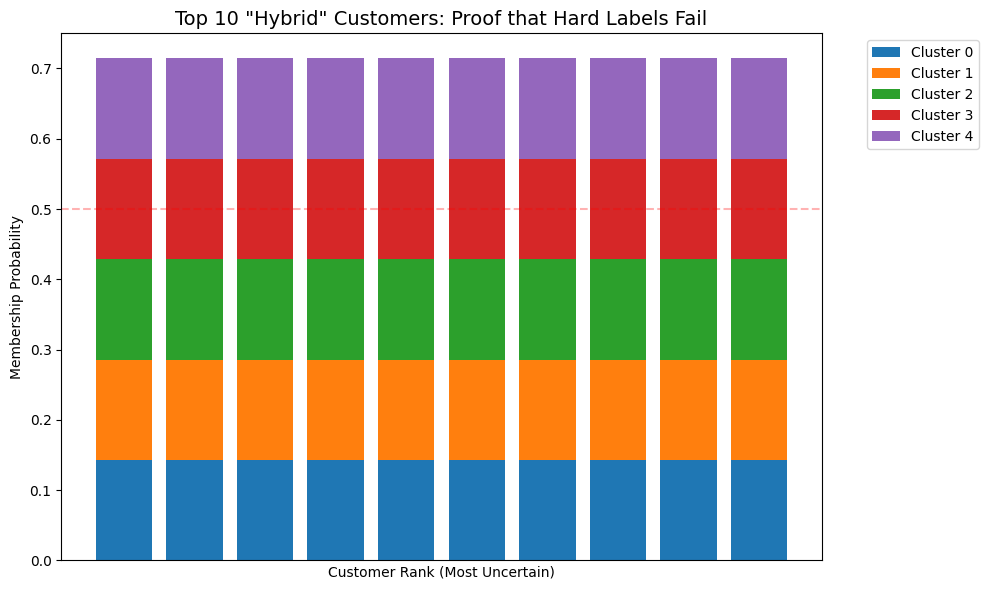

In [100]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Select the top 10 most "uncertain" customers
# (Those who sit on the fence between clusters)
uncertain_indices = np.argsort(max_memberships)[:10]
uncertain_data = u[:, uncertain_indices]

# 2. Plot their membership breakdown
plt.figure(figsize=(10, 6))
bottom = np.zeros(10)

for cluster_id in range(optimal_k):
    plt.bar(range(10), uncertain_data[cluster_id], bottom=bottom, label=f'Cluster {cluster_id}')
    bottom += uncertain_data[cluster_id]

plt.title('Top 10 "Hybrid" Customers: Proof that Hard Labels Fail', fontsize=14)
plt.ylabel('Membership Probability')
plt.xlabel('Customer Rank (Most Uncertain)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([]) # Hide x-axis numbers for clean look
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3, label='Hard Threshold')
plt.tight_layout()
plt.savefig('charts/top10hybrid_customers.png', dpi=300, bbox_inches='tight')
plt.show()

In [93]:
# Get the highest membership probability for each customer
max_memberships = np.max(u, axis=0)

# Get the hard labels (what K-Means would produce)
hard_labels = np.argmax(u, axis=0)

# Create a DataFrame to analyze the results
fuzzy_df = pd.DataFrame(customer_features['customer_id'])
fuzzy_df['hard_cluster'] = hard_labels
fuzzy_df['max_membership'] = max_memberships
fuzzy_df['uncertainty'] = 1 - max_memberships

# Show the customers that sit on the fence (High Uncertainty)
ambiguous_customers = fuzzy_df.sort_values('uncertainty', ascending=False).head(15)
print("Top 15 'Hybrid' Customers (Hard Clustering fails here):")
print(ambiguous_customers)

Top 15 'Hybrid' Customers (Hard Clustering fails here):
      customer_id  hard_cluster  max_membership  uncertainty
0               1             3        0.228427     0.771573
14             15             2        0.294264     0.705736
11             12             2        0.296680     0.703320
12             13             2        0.312295     0.687705
1177         1222             3        0.312977     0.687023
2327         2535             2        0.314963     0.685037
2               3             3        0.317316     0.682684
15             16             1        0.327537     0.672463
24             25             2        0.332686     0.667314
670           682             1        0.332879     0.667121
1468         1533             0        0.336463     0.663537
74             75             2        0.338427     0.661573
1724         1820             1        0.347158     0.652842
1388         1447             0        0.352723     0.647277
2030         2172            

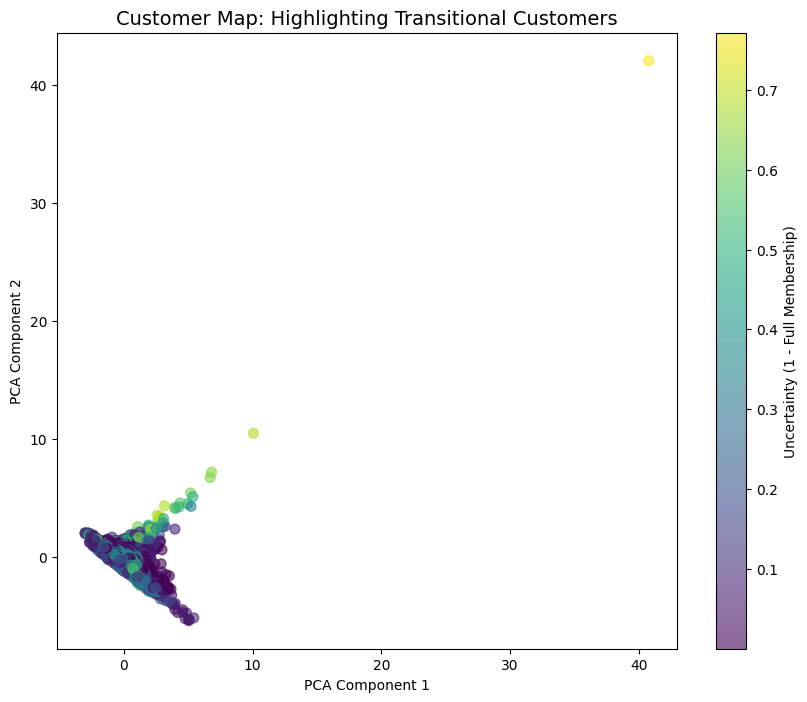

In [101]:
# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
# Color by uncertainty: Lighter/Brighter colors = More ambiguous customers
scatter = plt.scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    c=fuzzy_df['uncertainty'], 
    cmap='viridis', 
    s=50, 
    alpha=0.6
)
plt.colorbar(scatter, label='Uncertainty (1 - Full Membership)')
plt.title('Customer Map: Highlighting Transitional Customers', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.savefig('charts/transinional_customers.png', dpi=300, bbox_inches='tight')
plt.show()